# Day 15: Executive Hotel Booking EDA

This notebook analyzes hotel-booking demand, cancellation risk, revenue, guest behavior, distribution channels, and operational experience. The analysis is designed to support executive decisions about inventory, pricing, acquisition, and service quality.

## Executive questions

- Which hotel types and locations generate the most revenue?
- Where is cancellation risk concentrated?
- How do lead time, booking channels, room assignment, and guest type relate to outcomes?
- What operational patterns are associated with satisfaction?

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

source_path = Path(r'c:\Users\HP\Searches\Internship\Day15_Executive_Hotel_Booking_EDA_Dataset.csv.crdownload')
df = pd.read_csv(source_path, parse_dates=['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date'])
text_columns = df.select_dtypes(include='object').columns
for column in text_columns:
    df[column] = df[column].str.strip()
for column in ['Hotel_Type', 'Hotel_Location', 'Market_Segment', 'Distribution_Channel', 'Customer_Type', 'Meal_Type', 'Deposit_Type']:
    df[column] = df[column].fillna('Unknown')
df['Hotel_Type'] = df['Hotel_Type'].str.title()
df['Hotel_Location'] = df['Hotel_Location'].replace({'': 'Unknown'}).fillna('Unknown')
df['Children'] = df['Children'].fillna(0)
df = df.drop_duplicates().reset_index(drop=True)
df['Booking_Month'] = df['Booking_Date'].dt.to_period('M').astype(str)
df['Arrival_Month'] = df['Arrival_Date'].dt.to_period('M').astype(str)
df['Guests'] = df['Adults'] + df['Children'] + df['Babies']
df['Room_Changed'] = df['Room_Type_Reserved'] != df['Room_Type_Assigned']
df['Cancellation_Label'] = df['Is_Canceled'].map({0: 'Not canceled', 1: 'Canceled'})
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 13})

print(f'Rows after deduplication: {df.shape[0]:,}, columns: {df.shape[1]}')
print(f'Duplicate rows: {df.duplicated().sum():,}')
print(f'Total missing values: {int(df.isna().sum().sum()):,}')
display(df.head())
display(df[['Lead_Time_Days', 'Total_Nights', 'ADR', 'Estimated_Revenue', 'Satisfaction_Score']].describe().round(2))

Rows after deduplication: 25,000, columns: 40
Duplicate rows: 0
Total missing values: 21,587


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Booking_Month,Arrival_Month,Guests,Room_Changed,Cancellation_Label
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,4.37,No-Show,1,2025-07-07,714.65,2024-07,2025-07,2.0,False,Canceled
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,3.63,Canceled,1,2025-02-09,377.43,2024-05,2025-02,4.0,False,Canceled
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,3.70,Check-Out,0,2024-06-20,296.06,2024-05,2024-06,4.0,False,Not canceled
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,3.18,Check-Out,0,2024-04-08,333.63,2024-03,2024-04,2.0,False,Not canceled
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,3.79,Check-Out,0,2025-06-01,230.50,2024-08,2025-05,4.0,False,Not canceled


,Lead_Time_Days,Total_Nights,ADR,Estimated_Revenue,Satisfaction_Score
count,25000.00,25000.00,24920.00,25000.00,24840.00
mean,182.22,3.69,140.61,535.37,3.85
std,105.63,2.09,47.80,389.64,0.41
min,0.00,1.00,30.80,31.82,0.30
25%,91.00,2.00,105.60,230.62,3.59
50%,182.00,4.00,134.40,448.74,3.86
75%,273.00,5.00,169.08,737.57,4.13
max,920.00,45.00,710.50,3256.02,5.90


## 1. Booking and arrival volume over time

Monthly booking and arrival counts reveal seasonality and planning cycles.

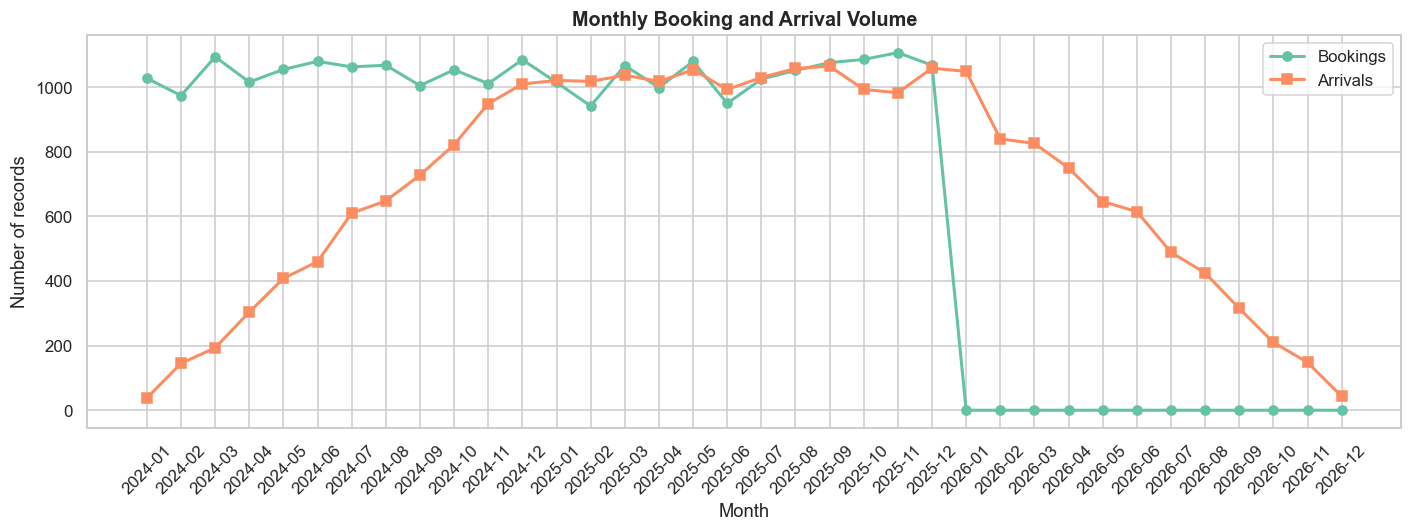

Interpretation: bookings peak in 2025-11 (1,107), while arrivals peak in 2025-09 (1,065). These peaks can guide staffing and inventory planning.


In [26]:
monthly_bookings = df.groupby('Booking_Month').size()
monthly_arrivals = df.groupby('Arrival_Month').size()
time_index = sorted(set(monthly_bookings.index) | set(monthly_arrivals.index))
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(time_index, monthly_bookings.reindex(time_index, fill_value=0), marker='o', linewidth=2, label='Bookings')
ax.plot(time_index, monthly_arrivals.reindex(time_index, fill_value=0), marker='s', linewidth=2, label='Arrivals')
ax.set_title('Monthly Booking and Arrival Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Number of records')
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout(); plt.show()
peak_booking_month = monthly_bookings.idxmax()
peak_arrival_month = monthly_arrivals.idxmax()
print(f'Interpretation: bookings peak in {peak_booking_month} ({monthly_bookings.max():,}), while arrivals peak in {peak_arrival_month} ({monthly_arrivals.max():,}). These peaks can guide staffing and inventory planning.')

## 2. Revenue by hotel type and location

These bar charts compare total estimated revenue and average daily rate across the portfolio.

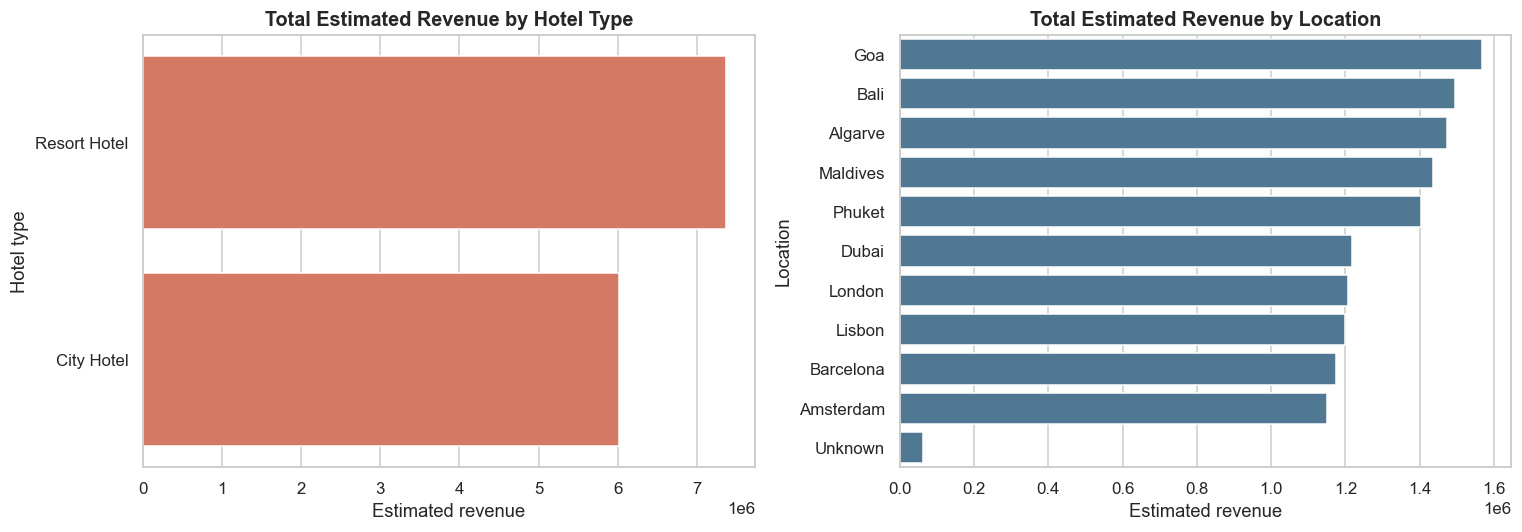

Interpretation: Resort Hotel contributes the most estimated revenue (7,365,875), and Goa is the leading location (1,568,006).


In [27]:
hotel_summary = df.groupby('Hotel_Type').agg(Total_Revenue=('Estimated_Revenue', 'sum'), Average_ADR=('ADR', 'mean'), Bookings=('Booking_ID', 'count')).sort_values('Total_Revenue', ascending=False)
location_summary = df.groupby('Hotel_Location').agg(Total_Revenue=('Estimated_Revenue', 'sum'), Average_ADR=('ADR', 'mean')).sort_values('Total_Revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=hotel_summary.reset_index(), x='Total_Revenue', y='Hotel_Type', color='#e76f51', order=hotel_summary.index, ax=axes[0])
sns.barplot(data=location_summary.reset_index(), x='Total_Revenue', y='Hotel_Location', color='#457b9d', order=location_summary.index, ax=axes[1])
axes[0].set_title('Total Estimated Revenue by Hotel Type'); axes[0].set_xlabel('Estimated revenue'); axes[0].set_ylabel('Hotel type')
axes[1].set_title('Total Estimated Revenue by Location'); axes[1].set_xlabel('Estimated revenue'); axes[1].set_ylabel('Location')
fig.tight_layout(); plt.show()
top_hotel_type = hotel_summary.index[0]
top_location = location_summary.index[0]
top_hotel_revenue = hotel_summary.loc[top_hotel_type, 'Total_Revenue']
top_location_revenue = location_summary.loc[top_location, 'Total_Revenue']
print(f'Interpretation: {top_hotel_type} contributes the most estimated revenue ({top_hotel_revenue:,.0f}), and {top_location} is the leading location ({top_location_revenue:,.0f}).')

## 3. Cancellation risk

Cancellation rates by hotel type and market segment identify where confirmed demand is most fragile.

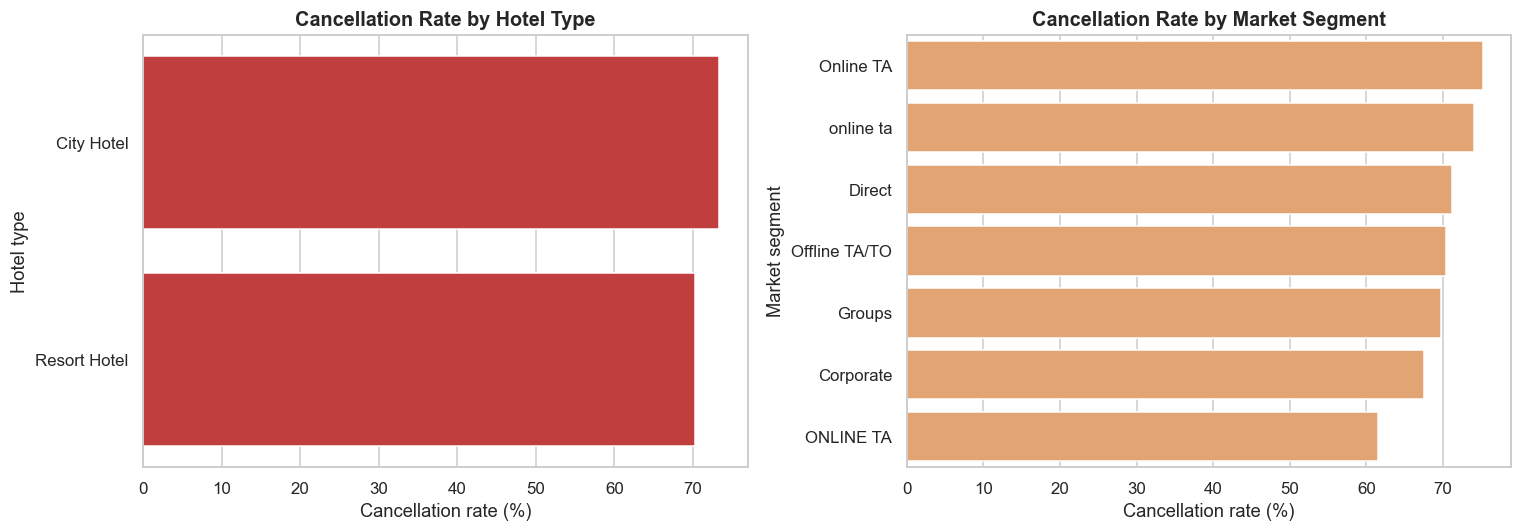

Interpretation: City Hotel has the highest hotel-type cancellation rate (73.3%), while Online TA is the riskiest market segment (75.2%). These groups may benefit from deposits, reminders, or overbooking controls.


In [28]:
hotel_cancel = df.groupby('Hotel_Type')['Is_Canceled'].mean().sort_values(ascending=False).mul(100)
segment_cancel = df.groupby('Market_Segment')['Is_Canceled'].mean().sort_values(ascending=False).mul(100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=hotel_cancel.values, y=hotel_cancel.index, color='#d62828', ax=axes[0])
sns.barplot(x=segment_cancel.values, y=segment_cancel.index, color='#f4a261', ax=axes[1])
axes[0].set_title('Cancellation Rate by Hotel Type'); axes[0].set_xlabel('Cancellation rate (%)'); axes[0].set_ylabel('Hotel type')
axes[1].set_title('Cancellation Rate by Market Segment'); axes[1].set_xlabel('Cancellation rate (%)'); axes[1].set_ylabel('Market segment')
fig.tight_layout(); plt.show()
highest_hotel_cancel = hotel_cancel.index[0]
highest_segment_cancel = segment_cancel.index[0]
print(f'Interpretation: {highest_hotel_cancel} has the highest hotel-type cancellation rate ({hotel_cancel.iloc[0]:.1f}%), while {highest_segment_cancel} is the riskiest market segment ({segment_cancel.iloc[0]:.1f}%). These groups may benefit from deposits, reminders, or overbooking controls.')

## 4. Lead time and cancellation

A box plot compares how far in advance guests book across cancellation outcomes.

C:\Users\HP\AppData\Local\Temp\ipykernel_13760\835033385.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cancellation_Label', y='Lead_Time_Days', order=['Not canceled', 'Canceled'], palette='Set2', ax=ax)


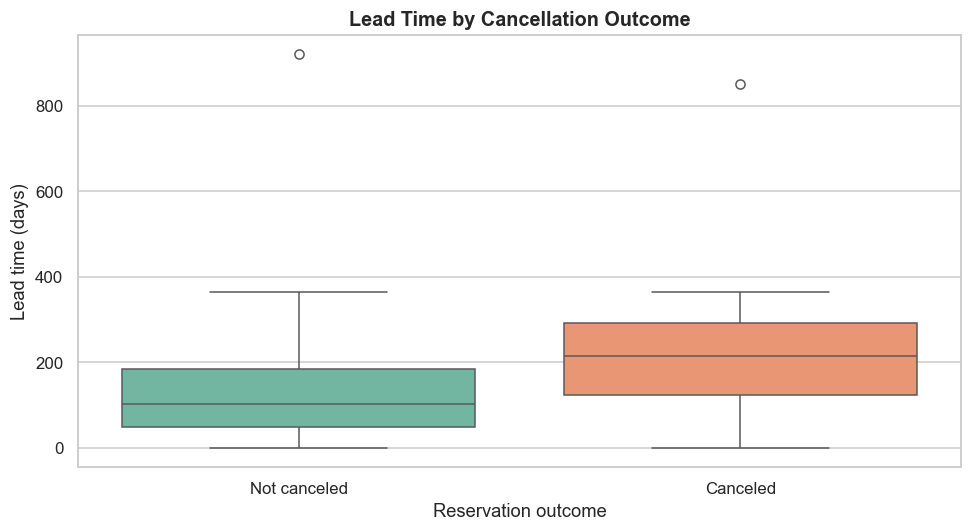

Interpretation: the median lead time is 214 days for canceled bookings versus 103 days for bookings that were not canceled. Longer lead time is a useful risk signal, although it is not proof of cancellation intent.


In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Cancellation_Label', y='Lead_Time_Days', order=['Not canceled', 'Canceled'], palette='Set2', ax=ax)
ax.set_title('Lead Time by Cancellation Outcome'); ax.set_xlabel('Reservation outcome'); ax.set_ylabel('Lead time (days)')
fig.tight_layout(); plt.show()
median_lead_time = df.groupby('Cancellation_Label')['Lead_Time_Days'].median()
canceled_median = median_lead_time['Canceled']
not_canceled_median = median_lead_time['Not canceled']
print(f'Interpretation: the median lead time is {canceled_median:.0f} days for canceled bookings versus {not_canceled_median:.0f} days for bookings that were not canceled. Longer lead time is a useful risk signal, although it is not proof of cancellation intent.')

## 5. Distribution channel performance

The count and revenue view compares acquisition volume with the value generated by each distribution channel.

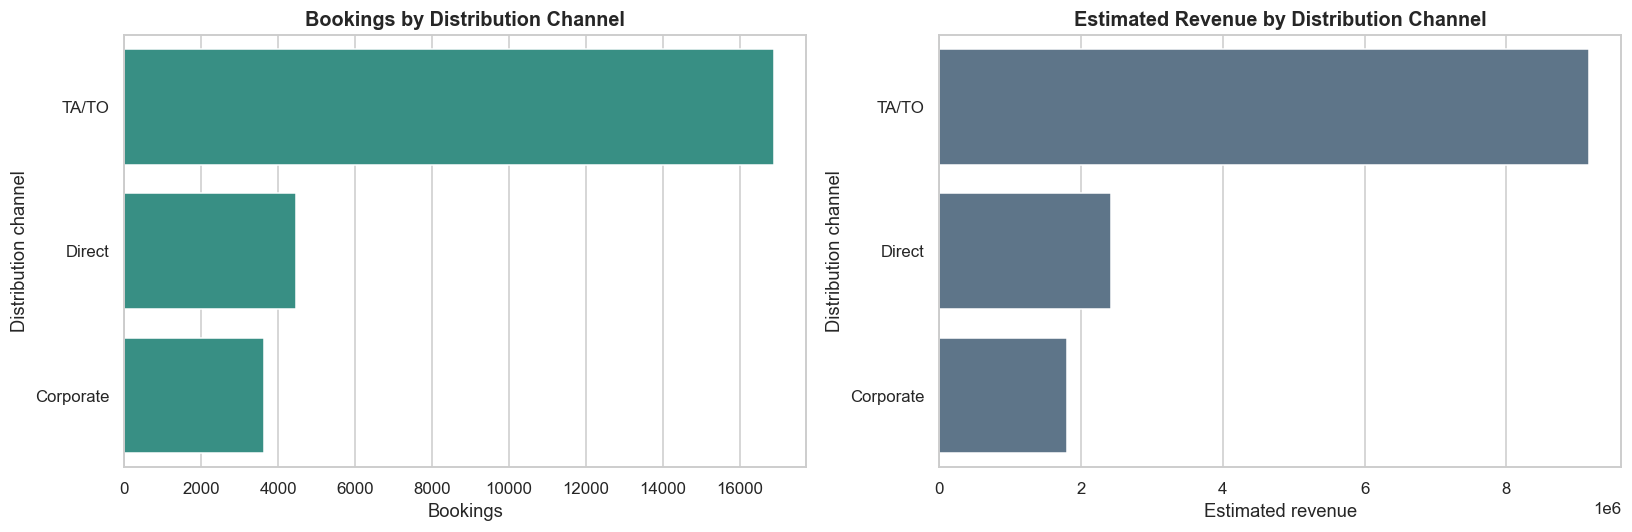

Interpretation: TA/TO generates the most estimated revenue (9,164,131). Comparing the two panels shows whether channel scale and channel value are aligned.


In [30]:
channel_summary = df.groupby('Distribution_Channel').agg(Bookings=('Booking_ID', 'count'), Revenue=('Estimated_Revenue', 'sum')).sort_values('Revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=channel_summary.reset_index().sort_values('Bookings', ascending=False), x='Bookings', y='Distribution_Channel', color='#2a9d8f', order=channel_summary.sort_values('Bookings', ascending=False).index, ax=axes[0])
sns.barplot(data=channel_summary.reset_index(), x='Revenue', y='Distribution_Channel', color='#577590', order=channel_summary.index, ax=axes[1])
axes[0].set_title('Bookings by Distribution Channel'); axes[0].set_xlabel('Bookings'); axes[0].set_ylabel('Distribution channel')
axes[1].set_title('Estimated Revenue by Distribution Channel'); axes[1].set_xlabel('Estimated revenue'); axes[1].set_ylabel('Distribution channel')
fig.tight_layout(); plt.show()
top_channel = channel_summary.index[0]
top_channel_revenue = channel_summary.loc[top_channel, 'Revenue']
print(f'Interpretation: {top_channel} generates the most estimated revenue ({top_channel_revenue:,.0f}). Comparing the two panels shows whether channel scale and channel value are aligned.')

## 6. ADR and estimated revenue

The scatter plot tests whether higher daily rates translate into higher booking-level revenue.

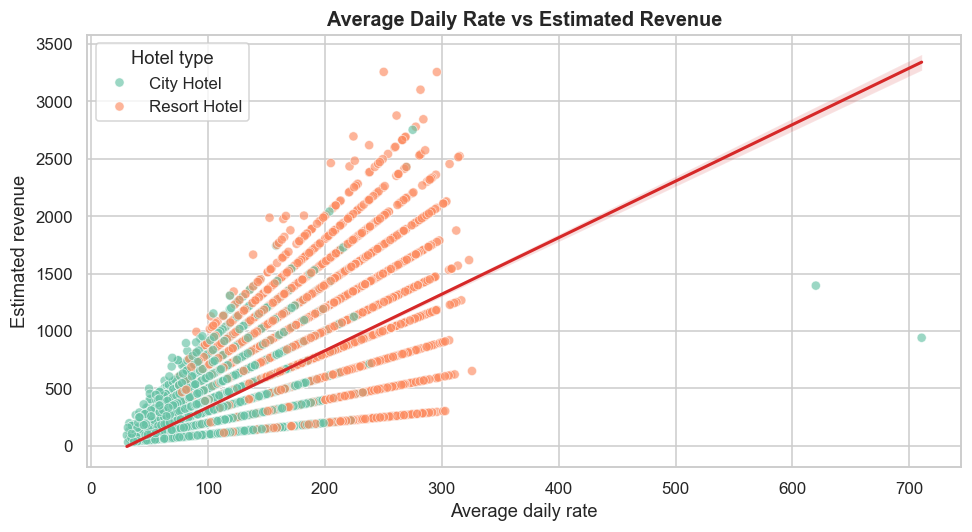

Interpretation: ADR and estimated revenue have a Pearson correlation of 0.60. The relationship should be read with total nights and booking volume because ADR alone does not determine revenue.


In [31]:
adr_revenue_corr = df['ADR'].corr(df['Estimated_Revenue'])
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='ADR', y='Estimated_Revenue', hue='Hotel_Type', alpha=0.65, ax=ax)
sns.regplot(data=df, x='ADR', y='Estimated_Revenue', scatter=False, color='#d62828', line_kws={'linewidth': 2}, ax=ax)
ax.set_title('Average Daily Rate vs Estimated Revenue'); ax.set_xlabel('Average daily rate'); ax.set_ylabel('Estimated revenue')
ax.legend(title='Hotel type')
fig.tight_layout(); plt.show()
print(f'Interpretation: ADR and estimated revenue have a Pearson correlation of {adr_revenue_corr:.2f}. The relationship should be read with total nights and booking volume because ADR alone does not determine revenue.')

## 7. Satisfaction and operational experience

The scatter plot examines whether guest satisfaction changes with waiting-list time, while the room-change bar chart highlights fulfillment differences.

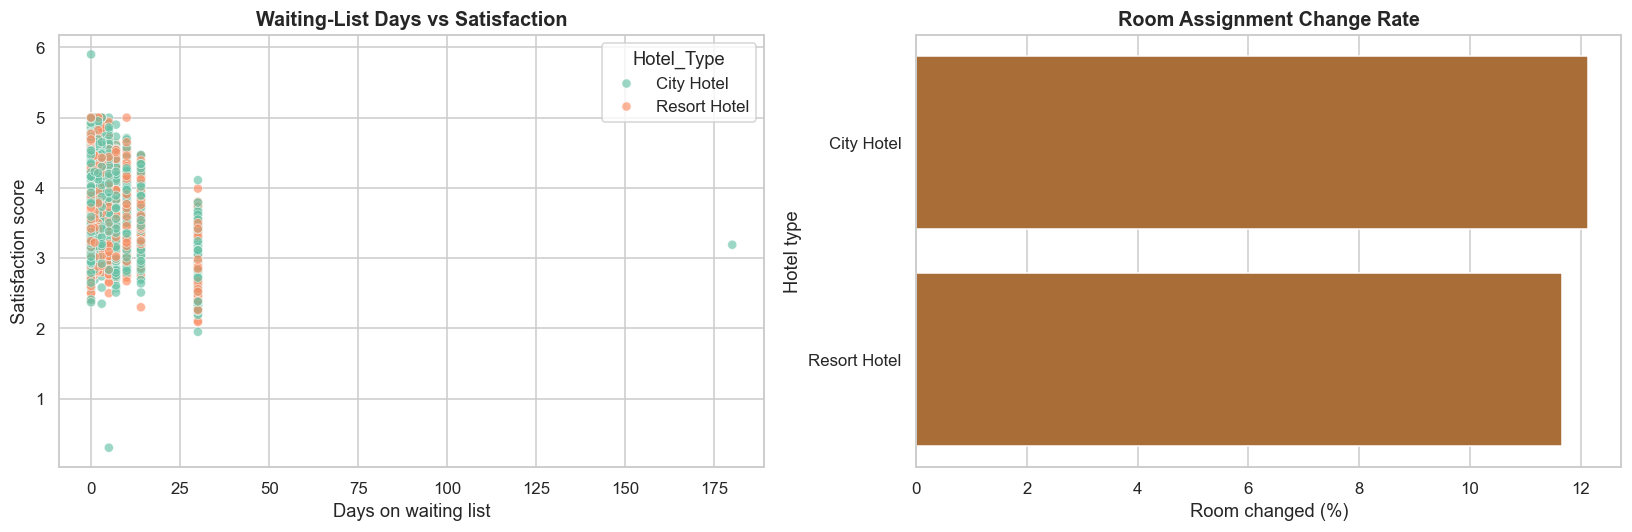

Interpretation: waiting-list days and satisfaction have a correlation of -0.28. City Hotel has the highest room-change rate (12.1%), which may warrant a closer look at room inventory and fulfillment policies.


In [32]:
waiting_corr = df['Days_In_Waiting_List'].corr(df['Satisfaction_Score'])
room_change_rate = df.groupby('Hotel_Type')['Room_Changed'].mean().mul(100).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='Days_In_Waiting_List', y='Satisfaction_Score', hue='Hotel_Type', alpha=0.65, ax=axes[0])
sns.barplot(x=room_change_rate.values, y=room_change_rate.index, color='#bc6c25', ax=axes[1])
axes[0].set_title('Waiting-List Days vs Satisfaction'); axes[0].set_xlabel('Days on waiting list'); axes[0].set_ylabel('Satisfaction score')
axes[1].set_title('Room Assignment Change Rate'); axes[1].set_xlabel('Room changed (%)'); axes[1].set_ylabel('Hotel type')
fig.tight_layout(); plt.show()
print(f'Interpretation: waiting-list days and satisfaction have a correlation of {waiting_corr:.2f}. {room_change_rate.index[0]} has the highest room-change rate ({room_change_rate.iloc[0]:.1f}%), which may warrant a closer look at room inventory and fulfillment policies.')

## 8. Guest profile and repeat behavior

The count plot shows the customer mix, and the repeat-guest comparison indicates where retention is concentrated.

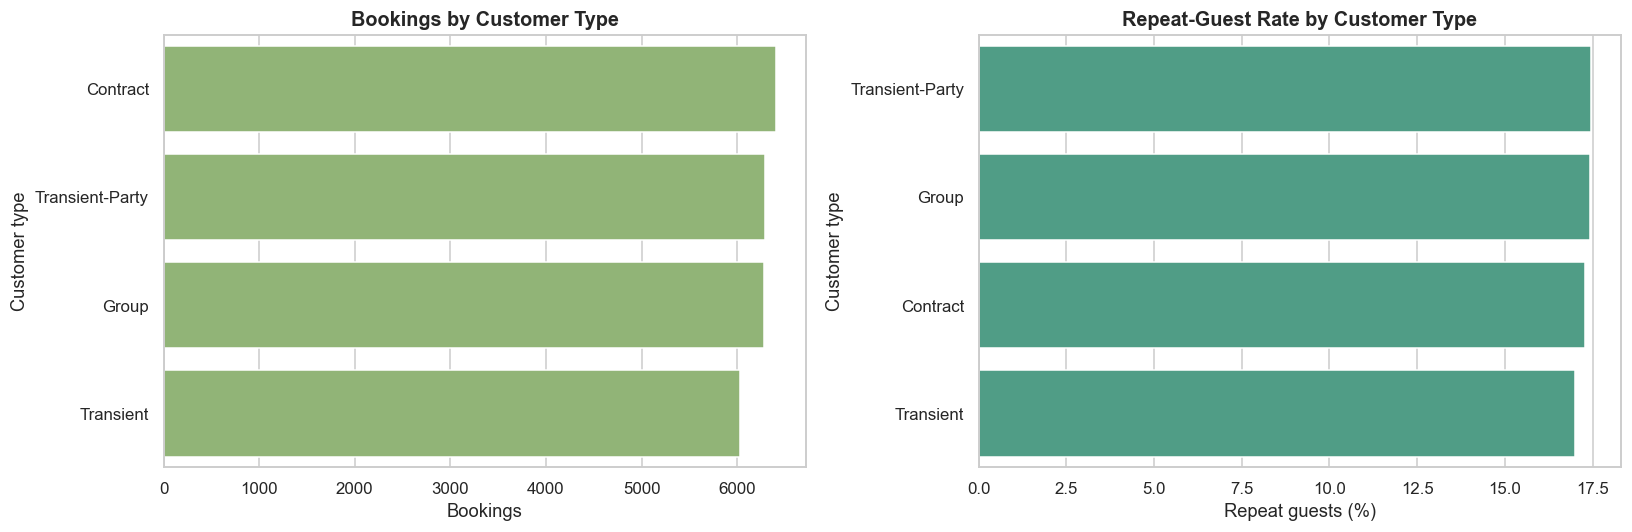

Interpretation: Transient-Party has the highest repeat-guest rate (17.4%), indicating the customer group with the strongest observed retention signal.


In [33]:
repeat_rates = df.groupby('Customer_Type')['Is_Repeated_Guest'].mean().mul(100).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, y='Customer_Type', order=df['Customer_Type'].value_counts().index, color='#90be6d', ax=axes[0])
sns.barplot(x=repeat_rates.values, y=repeat_rates.index, color='#43aa8b', ax=axes[1])
axes[0].set_title('Bookings by Customer Type'); axes[0].set_xlabel('Bookings'); axes[0].set_ylabel('Customer type')
axes[1].set_title('Repeat-Guest Rate by Customer Type'); axes[1].set_xlabel('Repeat guests (%)'); axes[1].set_ylabel('Customer type')
fig.tight_layout(); plt.show()
print(f'Interpretation: {repeat_rates.index[0]} has the highest repeat-guest rate ({repeat_rates.iloc[0]:.1f}%), indicating the customer group with the strongest observed retention signal.')

## 9. Correlation heatmap

The heatmap summarizes relationships among demand, pricing, stay, cancellation, and satisfaction metrics.

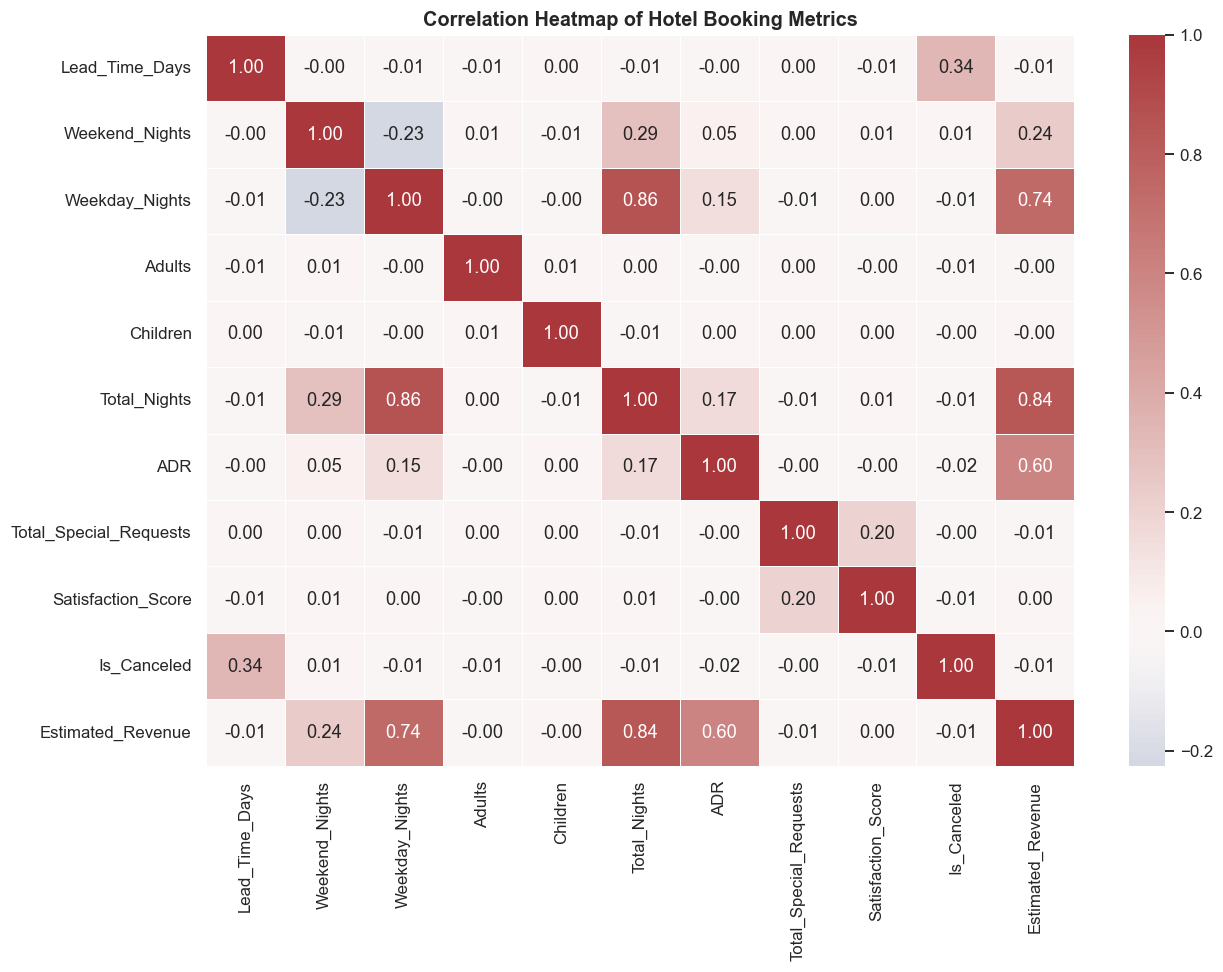

Interpretation: the strongest absolute relationship is between Weekday_Nights and Total_Nights (0.86). This pair is a useful starting point for deeper modeling or business experimentation.


In [34]:
numeric_columns = ['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Total_Nights', 'ADR', 'Total_Special_Requests', 'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue']
correlations = df[numeric_columns].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='vlag', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Hotel Booking Metrics')
fig.tight_layout(); plt.show()
pair_values = correlations.where(~np.eye(correlations.shape[0], dtype=bool)).stack().abs().sort_values(ascending=False)
strongest_pair = pair_values.index[0]
strongest_value = correlations.loc[strongest_pair[0], strongest_pair[1]]
print(f'Interpretation: the strongest absolute relationship is between {strongest_pair[0]} and {strongest_pair[1]} ({strongest_value:.2f}). This pair is a useful starting point for deeper modeling or business experimentation.')

## Executive summary

This analysis gives leadership a practical view of hotel demand and commercial risk. Revenue concentration by hotel type and location can inform investment and inventory decisions. Cancellation differences by segment and lead time indicate where deposits, reminders, flexible-rate design, or controlled overbooking may protect occupancy. Distribution-channel comparisons should balance booking volume against revenue contribution and acquisition cost. ADR must be interpreted with total nights and booking volume, while satisfaction and room-change patterns can identify operational priorities. The correlation heatmap provides a compact shortlist of relationships for predictive cancellation modeling, revenue forecasting, and retention programs.

### Publishing note

The source file currently has a `.crdownload` extension even though it contains a complete CSV. Before publishing to GitHub, rename it to `Day15_Executive_Hotel_Booking_EDA_Dataset.csv` and update `source_path` in the first code cell to match.